In [1]:
!pip install -q opencv-python-headless matplotlib numpy torch torchvision segment-anything

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from google.colab import files
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [3]:
print("Upload ONE wind turbine image")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Using image:", img_path)

Upload ONE wind turbine image


Saving WhatsApp Image 2026-01-07 at 1.51.39 PM.jpeg to WhatsApp Image 2026-01-07 at 1.51.39 PM.jpeg
Using image: WhatsApp Image 2026-01-07 at 1.51.39 PM.jpeg


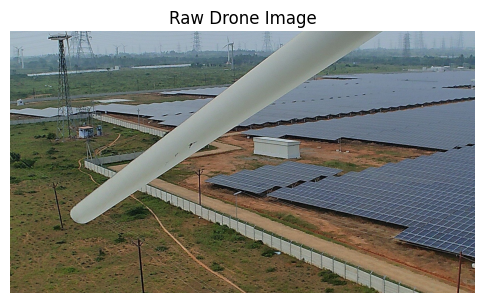

In [4]:
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title("Raw Drone Image")
plt.axis("off")
plt.show()

In [5]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device) # moves model to cpu or gpu
mask_generator = SamAutomaticMaskGenerator(
model=sam,
points_per_side=32,
pred_iou_thresh=0.9,
stability_score_thresh=0.92,
min_mask_region_area=1000
)
print("SAM loaded on", device)

SAM loaded on cpu


In [7]:
masks = mask_generator.generate(img_rgb)
print("Total masks:", len(masks))

Total masks: 85


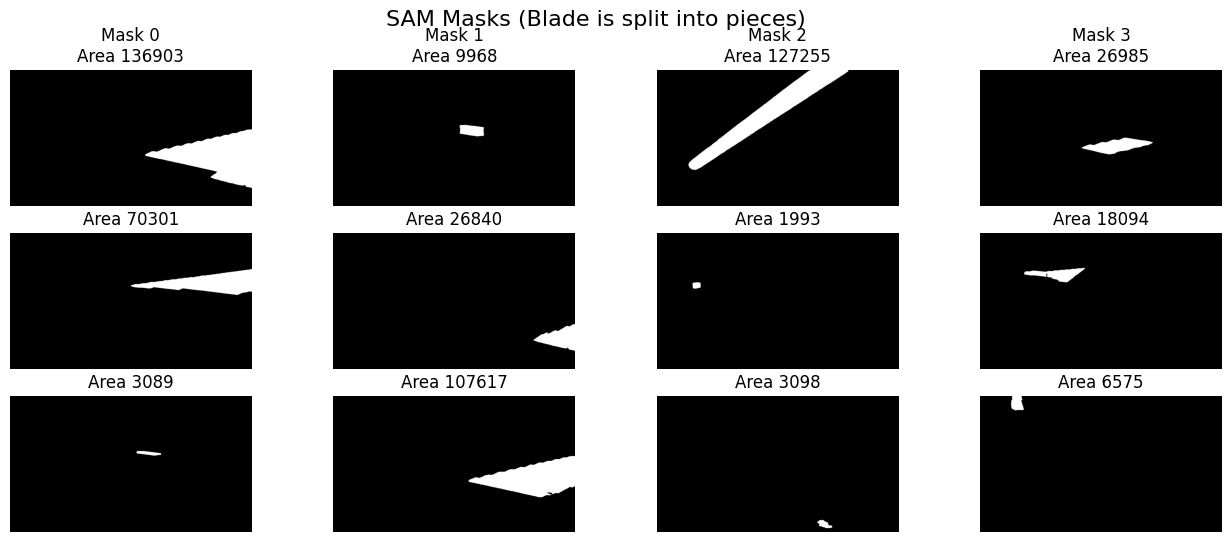

In [8]:
plt.figure(figsize=(16,6))
for i, m in enumerate(masks[:12]):
  plt.subplot(3,4,i+1)
  plt.imshow(m["segmentation"], cmap="gray")
  plt.title(f"Mask {i}\nArea {m['area']}")
  plt.axis("off")
plt.suptitle("SAM Masks (Blade is split into pieces)", fontsize=16)
plt.show()

In [9]:
blade_mask = masks[2]["segmentation"]


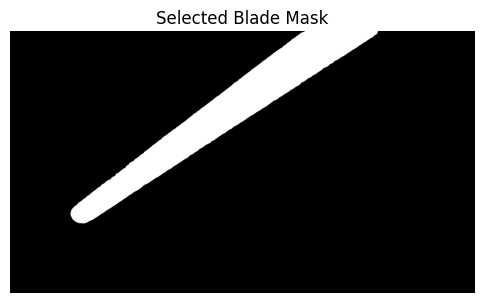

In [10]:
plt.figure(figsize=(6,4))
plt.imshow(blade_mask, cmap="gray")
plt.title("Selected Blade Mask")
plt.axis("off")
plt.show()

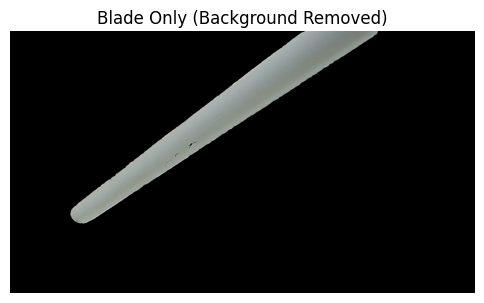

In [11]:
blade_only = img.copy()
blade_only[~blade_mask] = 0
plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(blade_only, cv2.COLOR_BGR2RGB))
plt.title("Blade Only (Background Removed)")
plt.axis("off")
plt.show()

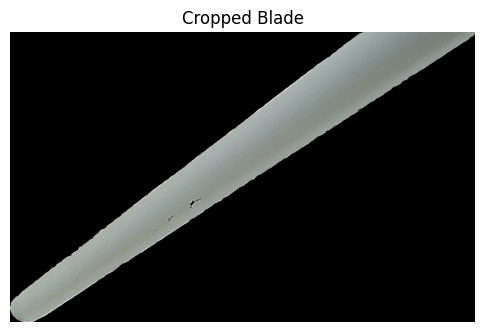

In [ ]:
ys, xs = np.where(blade_mask)
y1, y2 = ys.min(), ys.max() 
x1, x2 = xs.min(), xs.max()
blade_only = blade_only[y1:y2, x1:x2]
blade_mask = blade_mask[y1:y2, x1:x2]
plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(blade_only, cv2.COLOR_BGR2RGB))
plt.title("Cropped Blade")
plt.axis("off")
plt.show()

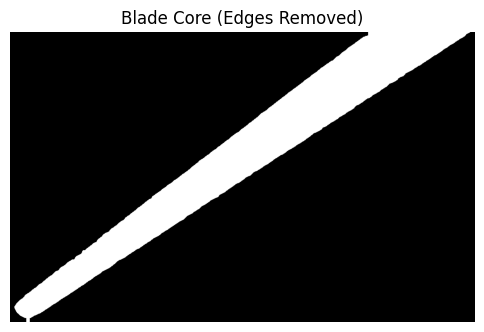

In [13]:
blade_core = cv2.erode(
blade_mask.astype(np.uint8),
np.ones((9,9), np.uint8),
iterations=2
).astype(bool)
plt.figure(figsize=(6,4))
plt.imshow(blade_core, cmap="gray")
plt.title("Blade Core (Edges Removed)")
plt.axis("off")
plt.show()

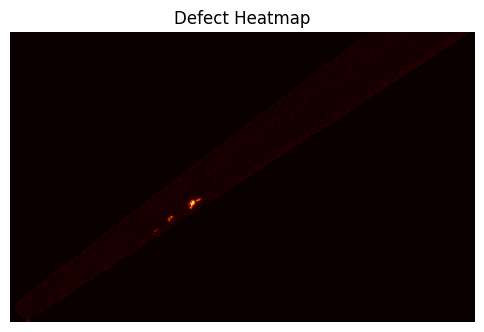

In [14]:
gray = cv2.cvtColor(blade_only, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
local_mean = cv2.GaussianBlur(gray, (41,41), 0)
heatmap = np.abs(gray - local_mean)
heatmap[~blade_core] = 0
heatmap = (heatmap / heatmap.max() * 255).astype(np.uint8)
plt.figure(figsize=(6,4))
plt.imshow(heatmap, cmap="hot")
plt.title("Defect Heatmap")
plt.axis("off")
plt.show()

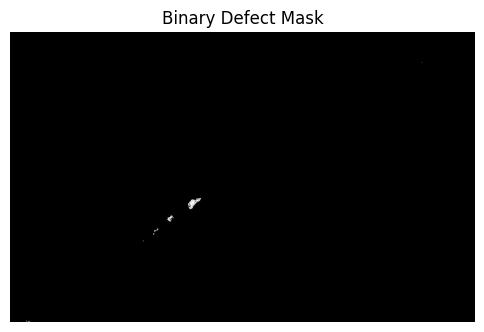

In [15]:
_, binary = cv2.threshold(heatmap, 35, 255, cv2.THRESH_BINARY)
binary[~blade_core] = 0
plt.figure(figsize=(6,4))
plt.imshow(binary, cmap="gray")
plt.title("Binary Defect Mask")
plt.axis("off")
plt.show()

In [16]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
defects = []
for cnt in contours:
  area = cv2.contourArea(cnt)
  if area > 50:
    defects.append(cnt)
print("Defects found:", len(defects))

Defects found: 2


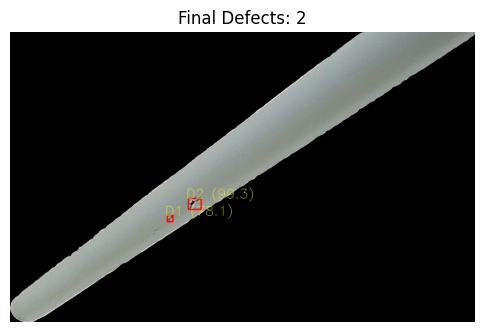

In [ ]:
final = blade_only.copy()
for i, cnt in enumerate(defects):
  mask = np.zeros(heatmap.shape, dtype=np.uint8)
  cv2.drawContours(mask, [cnt], -1, 255, -1)
  mean_intensity = cv2.mean(heatmap, mask=mask)[0]

  x,y,w,h = cv2.boundingRect(cnt)
  cv2.rectangle(final, (x,y), (x+w,y+h), (0,0,255), 2)
  cv2.putText(final, f"D{i+1} ({mean_intensity:.1f})", (x-5,y), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,255), 1)

plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.title(f"Final Defects: {len(defects)}")
plt.axis("off")
plt.show()

In [20]:
for i, cnt in enumerate(defects):
  mask = np.zeros(heatmap.shape, dtype=np.uint8)
  cv2.drawContours(mask, [cnt], -1, 255, -1)
  # Calculate the mean heatmap intensity within the defect contour
  mean_intensity = cv2.mean(heatmap, mask=mask)[0]
  print(f"Defect D{i+1} Severity Score (Avg Heatmap Intensity): {mean_intensity:.2f}")

Defect D1 Severity Score (Avg Heatmap Intensity): 78.08
Defect D2 Severity Score (Avg Heatmap Intensity): 99.30
